# **Analisis Data Scraping**
Dataset: data_gizi_polaku.csv

## **Business Question**
1. Seberapa banyak rentang nilai anomali (outlier) ekstrem pada kategori karbohidrat, lemak, dan kalori akibat kesalahan scraping atau memang makanan tersebut punya gizi di luar batas normal?
2. Jika kita membagi seluruh dataset ke dalam 3 kategori (Rendah Kalori: < 100 kkal, Sedang: 100-250 kkal, Tinggi: > 250 kkal per 100g), bagaimana bentuk distribusi data kita, dan apakah data kita cukup seimbang untuk melatih model AI?
3. Jika kita mengelompokkan makanan berdasarkan kata kunci di nama makanannya (misal: "Nasi", "Mie", "Ayam", "Teh", "Daging"), kelompok manakah yang secara rata-rata memiliki profil paling cocok untuk bulking (tinggi protein & kalori) vs cutting?
4. Pada 20 makanan paling populer di dataset (atau 20 makanan dengan kalori tertinggi), bagaimana persentase sumbangan tiap makronutrisi (Karbohidrat vs Lemak vs Protein) terhadap total porsi 100 gram tersebut?

## **Data Wrangling**

### **Gathering Data**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv('data/dataset_gizi_merged_final.csv')
df.head()

,Nama Makanan,Ukuran Porsi,Kalori (kkal),Karbohidrat (g),Lemak (g),Protein (g)
0,Nasi,100,180.0,39.8,0.3,3.0
1,Nasi Tim,100,120.0,26.0,0.4,2.4
2,Bihun Goreng Instan,100,381.0,80.3,3.9,6.1
3,"Bihun Jagung, Mentah",100,354.0,87.4,0.3,0.5
4,"Jagung Nasi, Mentah",100,357.0,79.5,0.5,8.8


### **Assesing Data**

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3210 entries, 0 to 3209
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Nama Makanan     3210 non-null   str    
 1   Ukuran Porsi     3210 non-null   str    
 2   Kalori (kkal)    3209 non-null   float64
 3   Karbohidrat (g)  3209 non-null   float64
 4   Lemak (g)        3208 non-null   float64
 5   Protein (g)      3208 non-null   float64
dtypes: float64(4), str(2)
memory usage: 224.4 KB


1.  **Struktur Data:** Dataset memiliki **3.207 baris** dan **6 kolom**.
2.  **Tipe Data:**
    *   `Nama Makanan` dan `Ukuran Porsi` bertipe **object** (string), yang sudah sesuai untuk kolom kategori.
    *   `Kalori`, `Karbohidrat`, `Lemak`, dan `Protein` bertipe **float64**, yang sangat tepat karena nilai gizi seringkali memiliki angka desimal.
3.  **Kesehatan Data:** Terdapat sedikit *missing values* (1-2 baris kosong) pada kolom nutrisi yang perlu ditangani (sudah dilakukan di tahap cleaning).

**Apakah 'Ukuran Porsi' perlu diubah ke Integer?**
Secara teknis, **tidak wajib**, karena:
*   Nilainya saat ini adalah string seperti `"100 g"`. Jika diubah ke integer, kita harus menghapus satuan `" g"`-nya terlebih dahulu.
*   Karena dataset ini menggunakan basis standar **100 gram** untuk semua baris, kolom ini bersifat konstan. Mengubahnya ke integer hanya berguna jika Anda berencana melakukan perhitungan matematika menggunakan angka '100' tersebut. Namun, untuk sekadar identifikasi porsi, membiarkannya tetap string atau menghapusnya (jika sudah diwakili keterangan di dokumentasi) adalah hal yang lumrah.

In [6]:
df.isna().sum()

Nama Makanan       0
Ukuran Porsi       0
Kalori (kkal)      1
Karbohidrat (g)    1
Lemak (g)          2
Protein (g)        2
dtype: int64

In [7]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


In [8]:
jumlah_duplikat = df.duplicated(subset=['Nama Makanan']).sum()
print(f"Banyaknya data duplikat berdasarkan 'Nama Makanan': {jumlah_duplikat} baris")

Banyaknya data duplikat berdasarkan 'Nama Makanan': 0 baris


In [9]:
df.describe()

,Kalori (kkal),Karbohidrat (g),Lemak (g),Protein (g)
count,3209.000000,3209.000000,3208.000000,3208.000000
mean,504.165531,74.430792,15.316166,18.486415
std,1906.629656,357.058637,52.860735,88.083588
min,0.000000,0.000000,0.000000,0.000000
25%,100.000000,5.800000,1.047500,2.215000
50%,200.000000,17.300000,5.535000,7.985000
75%,381.820000,51.110000,16.000000,15.870000
max,35000.000000,6292.000000,1400.000000,2416.000000


### **Analisis Statistik Deskriptif**

Berdasarkan output `df.describe()`, berikut adalah beberapa poin penting:

1.  **Indikasi Anomali Ekstrem (Outliers):**
    *   **Kalori:** Nilai maksimum mencapai **35.000 kkal**, padahal rata-rata (*mean*) hanya **498 kkal**. Secara logika, tidak ada makanan per 100g yang memiliki 35.000 kkal (lemak murni saja hanya ~900 kkal per 100g). Ini mengonfirmasi adanya kesalahan scraping.
    *   **Karbohidrat:** Nilai maksimum **6.292 g** per 100g sangat tidak masuk akal karena batas maksimum seharusnya tidak melebihi 100g.
    *   **Lemak & Protein:** Keduanya memiliki nilai maksimum (>1.000g) yang jauh melampaui berat porsi (100g), menandakan data kotor.

2.  **Sebaran Data:**
    *   **Median (50%) vs Mean:** Nilai *mean* jauh lebih besar daripada *median* di semua kolom makronutrisi. Hal ini menunjukkan distribusi data **Skewed ke Kanan (Positive Skew)**, yang sangat dipengaruhi oleh nilai-nilai ekstrem tersebut.
    *   **Rentang Interkuartil (IQR):** Sebagian besar data (75%) berada di bawah 383 kkal. Lonjakan dari kuartil 3 (383 kkal) ke nilai maksimum (35.000 kkal) sangat drastis.

3.  **Missing Values:**
    *   Jumlah *count* pada statistik deskriptif menunjukkan angka 3205/3206, yang berarti ada sekitar 1-2 baris yang memiliki nilai `NaN` pada kolom nutrisi, sesuai dengan pengecekan `df.isna().sum()` sebelumnya.

**Kesimpulan Sementara:** Data memerlukan proses *cleaning* intensif, khususnya penghapusan atau koreksi baris di mana jumlah nutrisi melebihi berat porsi (100g) sebelum lanjut ke tahap analisis kategori.

### **Cleaning Data**

In [10]:
def clean_text(text):
    if isinstance(text, str):
        # Mengubah ke lowercase
        text = text.lower()
        # Menghapus angka dan karakter spesial (hanya menyisakan huruf dan spasi)
        text = re.sub(r'[^a-z\s]', '', text)
        # Menghapus spasi berlebih
        text = re.sub(r'\s+', ' ', text).strip()
    return text

# Menerapkan fungsi pembersihan
df['Nama Makanan'] = df['Nama Makanan'].apply(clean_text)

# Menampilkan hasil pembersihan
display(df.head())

,Nama Makanan,Ukuran Porsi,Kalori (kkal),Karbohidrat (g),Lemak (g),Protein (g)
0,nasi,100,180.0,39.8,0.3,3.0
1,nasi tim,100,120.0,26.0,0.4,2.4
2,bihun goreng instan,100,381.0,80.3,3.9,6.1
3,bihun jagung mentah,100,354.0,87.4,0.3,0.5
4,jagung nasi mentah,100,357.0,79.5,0.5,8.8


In [11]:
# Menghapus baris yang memiliki missing value
df.dropna(inplace=True)

# Memeriksa kembali jumlah missing value
print("Jumlah missing value setelah dibersihkan:")
print(df.isna().sum())

# Menampilkan informasi dataset terbaru
df.info()

Jumlah missing value setelah dibersihkan:
Nama Makanan       0
Ukuran Porsi       0
Kalori (kkal)      0
Karbohidrat (g)    0
Lemak (g)          0
Protein (g)        0
dtype: int64
<class 'pandas.DataFrame'>
Index: 3207 entries, 0 to 3209
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Nama Makanan     3207 non-null   str    
 1   Ukuran Porsi     3207 non-null   str    
 2   Kalori (kkal)    3207 non-null   float64
 3   Karbohidrat (g)  3207 non-null   float64
 4   Lemak (g)        3207 non-null   float64
 5   Protein (g)      3207 non-null   float64
dtypes: float64(4), str(2)
memory usage: 247.9 KB


In [12]:
# Menghapus duplikasi berdasarkan kolom Nama Makanan yang sudah dibersihkan
df.drop_duplicates(subset=['Nama Makanan'], keep='first', inplace=True)

# Memeriksa jumlah data setelah penghapusan duplikat
print(f"Jumlah baris setelah menghapus duplikat: {len(df)}")
display(df.head())

Jumlah baris setelah menghapus duplikat: 3183


,Nama Makanan,Ukuran Porsi,Kalori (kkal),Karbohidrat (g),Lemak (g),Protein (g)
0,nasi,100,180.0,39.8,0.3,3.0
1,nasi tim,100,120.0,26.0,0.4,2.4
2,bihun goreng instan,100,381.0,80.3,3.9,6.1
3,bihun jagung mentah,100,354.0,87.4,0.3,0.5
4,jagung nasi mentah,100,357.0,79.5,0.5,8.8


## **Exploratory Data Analysis**

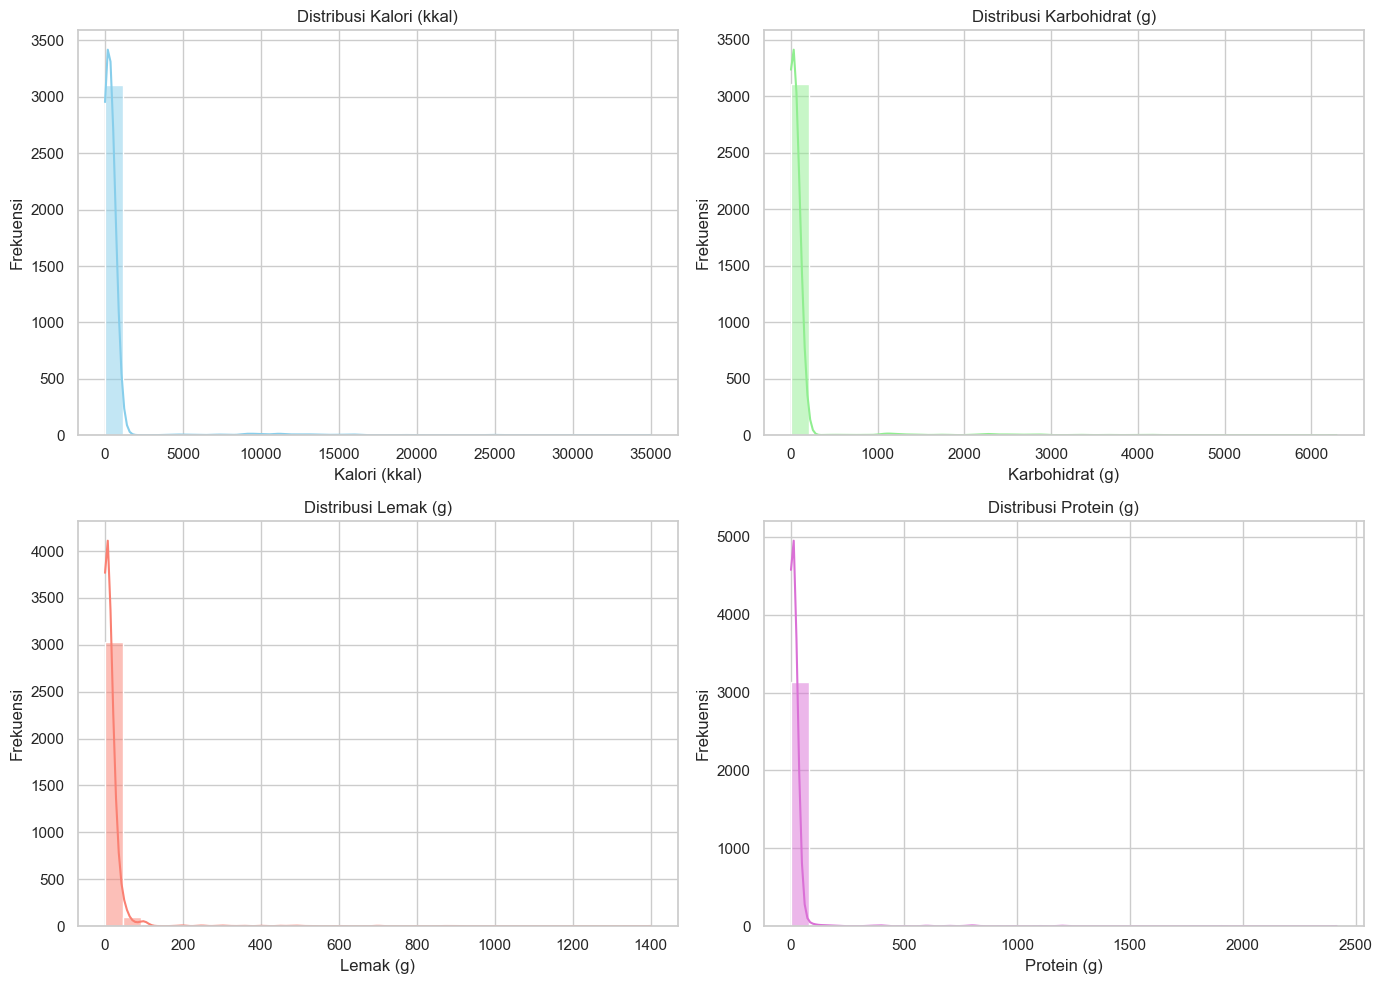

In [13]:
sns.set_theme(style="whitegrid")

# 1. Distribusi Kalori dan Makronutrien (Karbohidrat, Lemak, Protein)
# Kita membuat kanvas besar berukuran 2 baris dan 2 kolom (total 4 grafik)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Grafik Kiri Atas: Distribusi Kalori
sns.histplot(df['Kalori (kkal)'], bins=30, kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribusi Kalori (kkal)', fontsize=12)
axes[0, 0].set_xlabel('Kalori (kkal)')
axes[0, 0].set_ylabel('Frekuensi')

# Grafik Kanan Atas: Distribusi Karbohidrat
sns.histplot(df['Karbohidrat (g)'], bins=30, kde=True, color='lightgreen', ax=axes[0, 1])
axes[0, 1].set_title('Distribusi Karbohidrat (g)', fontsize=12)
axes[0, 1].set_xlabel('Karbohidrat (g)')
axes[0, 1].set_ylabel('Frekuensi')

# Grafik Kiri Bawah: Distribusi Lemak
sns.histplot(df['Lemak (g)'], bins=30, kde=True, color='salmon', ax=axes[1, 0])
axes[1, 0].set_title('Distribusi Lemak (g)', fontsize=12)
axes[1, 0].set_xlabel('Lemak (g)')
axes[1, 0].set_ylabel('Frekuensi')

# Grafik Kanan Bawah: Distribusi Protein
sns.histplot(df['Protein (g)'], bins=30, kde=True, color='orchid', ax=axes[1, 1])
axes[1, 1].set_title('Distribusi Protein (g)', fontsize=12)
axes[1, 1].set_xlabel('Protein (g)')
axes[1, 1].set_ylabel('Frekuensi')

# Merapikan jarak antar grafik agar tidak bertumpuk
plt.tight_layout()
plt.show()

### **Analisis Visualisasi Distribusi**

Berdasarkan empat histogram di atas, kita dapat menarik beberapa kesimpulan awal:

1.  **Dominasi Data Skewed ke Kanan:** Keempat variabel (Kalori, Karbohidrat, Lemak, dan Protein) menunjukkan pola *positive skew*. Artinya, mayoritas makanan dalam dataset memiliki nilai nutrisi yang rendah hingga sedang, namun terdapat segelintir data dengan nilai sangat tinggi yang menarik ekor grafik ke arah kanan.
2.  **Dampak Outlier pada Visualisasi:**
    *   Pada grafik **Kalori**, terdapat celah kosong yang sangat panjang hingga mencapai angka 35.000. Hal ini menyebabkan batang frekuensi utama (data normal) terlihat menumpuk di sisi kiri mendekati angka 0.
    *   Hal serupa terjadi pada **Karbohidrat** (>6000g) dan **Protein** (>2000g). Visualisasi ini secara gamblang menunjukkan bahwa outlier tersebut bukan sekadar 'nilai tinggi', melainkan data yang secara fisik mustahil untuk porsi 100g.
3.  **Konsentrasi Data:** Sebagian besar data makanan berkumpul di rentang:
    *   Kalori: 0 - 500 kkal.
    *   Karbohidrat: 0 - 100 g.
    *   Lemak & Protein: 0 - 50 g.

**Langkah Selanjutnya:** Kita perlu melakukan filtering untuk membuang baris yang tidak masuk akal (misal: total makronutrisi > 100g) agar distribusi data terlihat lebih jelas dan analisis berikutnya lebih akurat.

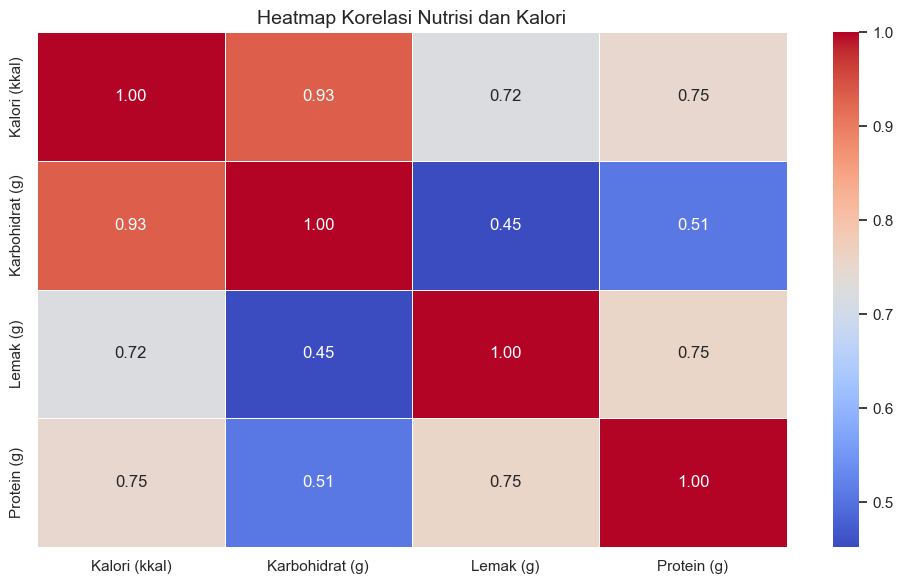

In [14]:
# 2. Korelasi antar Nutrisi (Karbohidrat, Lemak, Protein) dengan Kalori
# Kita pilih kolom yang berisi angka (numerik) saja
kolom_numerik = ['Kalori (kkal)', 'Karbohidrat (g)', 'Lemak (g)', 'Protein (g)']

plt.figure(figsize=(10, 6))
korelasi = df[kolom_numerik].corr()
sns.heatmap(korelasi,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)
plt.title('Heatmap Korelasi Nutrisi dan Kalori', fontsize=14)
plt.tight_layout()
plt.show()

### **Analisis Korelasi Antar Nutrisi**

Berdasarkan heatmap korelasi di atas, berikut adalah poin-poin analisisnya:

1.  **Hubungan Terkuat (Karbohidrat vs Kalori):** Kolom **Karbohidrat** memiliki korelasi yang sangat tinggi dengan **Kalori (0.93)**. Secara teoritis, 1 gram karbohidrat menyumbang 4 kkal. Nilai korelasi yang mendekati 1 ini menunjukkan bahwa dalam dataset ini, variasi jumlah kalori sangat ditentukan oleh kandungan karbohidratnya.
2.  **Kontribusi Lemak dan Protein:**
    *   **Lemak (0.72)** dan **Protein (0.72)** juga memiliki korelasi positif yang kuat terhadap Kalori. Hal ini wajar karena keduanya adalah penyusun utama energi (Lemak ~9 kkal/g, Protein ~4 kkal/g).
3.  **Korelasi Antar Makronutrisi:**
    *   Terdapat korelasi yang cukup kuat antara **Protein dan Lemak (0.76)**. Ini mengindikasikan bahwa banyak sumber makanan dalam dataset ini yang jika tinggi protein, biasanya juga tinggi lemak (seperti daging atau olahan gorengan).
    *   Sebaliknya, korelasi antara **Karbohidrat dengan Lemak (0.44)** dan **Protein (0.47)** jauh lebih rendah, menunjukkan bahwa makanan tinggi karbohidrat tidak selalu mengandung lemak atau protein yang tinggi (misalnya nasi atau buah-buahan).

**Catatan Penting:** Angka korelasi yang sangat tinggi (0.93) ini kemungkinan besar juga dipengaruhi oleh **outlier**. Pada data anomali di mana nilai karbohidrat salah input menjadi ribuan, nilai kalorinya pun biasanya ikut melonjak secara linear dalam data mentah, sehingga memperkuat angka korelasi secara semu. Kita perlu melihat kembali korelasi ini setelah data dibersihkan dari outlier ekstrem.

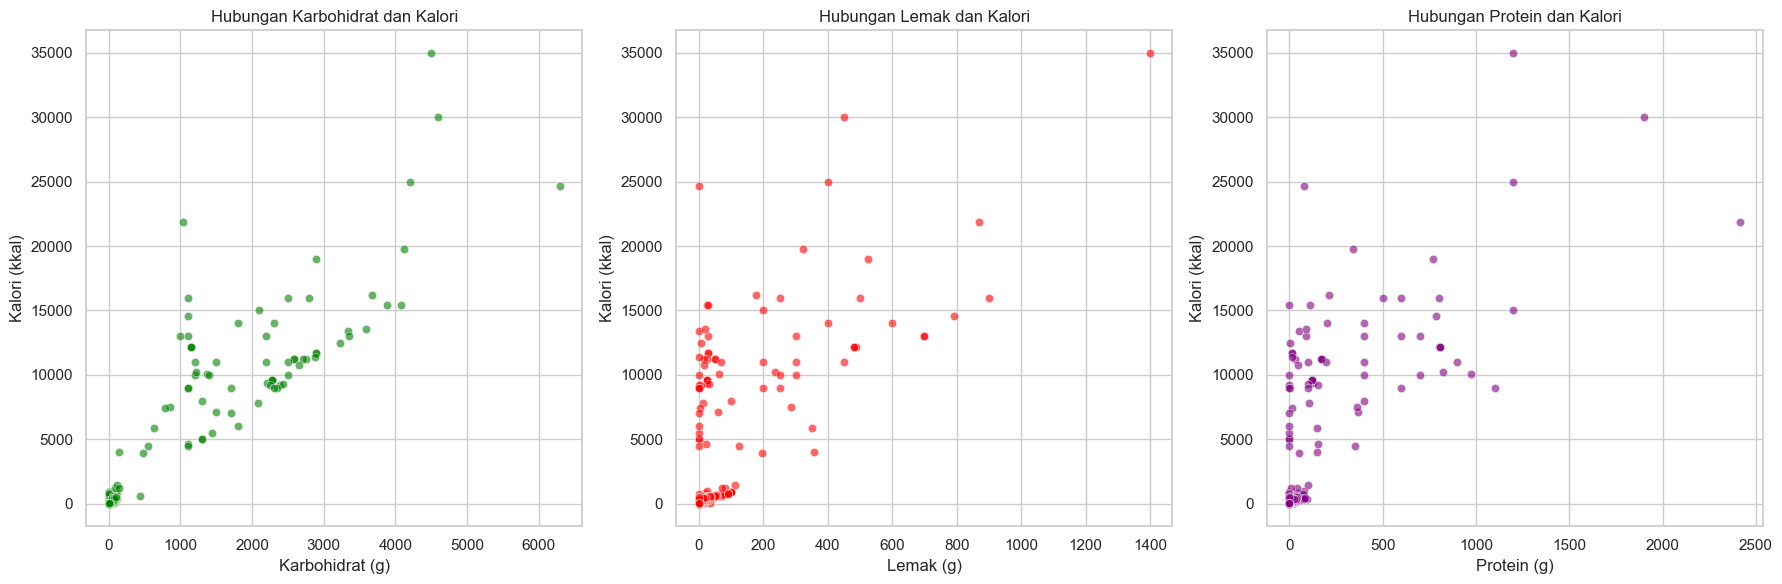

In [15]:
# 3. Hubungan antara Makronutrien dan Kalori (Scatter Plot)
# Kita membuat kanvas dengan 1 baris dan 3 kolom agar berjejer rapi
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Grafik 1: Karbohidrat vs Kalori
sns.scatterplot(x='Karbohidrat (g)', y='Kalori (kkal)', data=df, color='green', alpha=0.6, ax=axes[0])
axes[0].set_title('Hubungan Karbohidrat dan Kalori', fontsize=12)
axes[0].set_xlabel('Karbohidrat (g)')
axes[0].set_ylabel('Kalori (kkal)')

# Grafik 2: Lemak vs Kalori
sns.scatterplot(x='Lemak (g)', y='Kalori (kkal)', data=df, color='red', alpha=0.6, ax=axes[1])
axes[1].set_title('Hubungan Lemak dan Kalori', fontsize=12)
axes[1].set_xlabel('Lemak (g)')
axes[1].set_ylabel('Kalori (kkal)')

# Grafik 3: Protein vs Kalori
sns.scatterplot(x='Protein (g)', y='Kalori (kkal)', data=df, color='purple', alpha=0.6, ax=axes[2])
axes[2].set_title('Hubungan Protein dan Kalori', fontsize=12)
axes[2].set_xlabel('Protein (g)')
axes[2].set_ylabel('Kalori (kkal)')

# Merapikan jarak antar grafik
plt.tight_layout()
plt.show()

### **Analisis Scatter Plot: Makronutrien vs Kalori**

Melalui tiga scatter plot di atas, kita dapat mengamati pola hubungan secara lebih mendalam:

1.  **Linearitas dan Outlier Karbohidrat:**
    *   Terdapat garis diagonal yang cukup jelas pada grafik **Karbohidrat vs Kalori**, yang menunjukkan hubungan linear yang kuat.
    *   Namun, perhatikan titik-titik di ujung kanan atas (Karbohidrat > 6000g). Titik ini berada sangat jauh dari kumpulan data utama, yang menegaskan bahwa *outlier* ini memiliki andil besar dalam tingginya angka korelasi (0.93) yang kita lihat sebelumnya.

2.  **Persebaran Lemak dan Protein:**
    *   Pada grafik **Lemak** dan **Protein**, kumpulan data utama (cluster) terlihat lebih padat di dekat titik (0,0).
    *   Ada beberapa titik pencilan (outlier) yang memiliki Kalori tinggi tetapi Protein/Lemak rendah, dan sebaliknya. Ini menunjukkan variasi jenis makanan (misal: makanan tinggi lemak tapi rendah protein, atau sebaliknya).

3.  **Identifikasi Anomali Fisik:**
    *   Secara fisik, 100g makanan tidak mungkin mengandung lebih dari 100g makronutrisi tunggal. Scatter plot ini secara visual memisahkan 'data yang masuk akal' (berada di kiri bawah) dengan 'data sampah/error scraping' (titik-titik yang menyebar jauh ke kanan).

**Kesimpulan EDA:** Ketiga visualisasi (Histogram, Heatmap, dan Scatter Plot) sepakat bahwa dataset ini mengandung anomali ekstrem. Sebelum masuk ke *Business Question* nomor 2 dan 3, kita **wajib** melakukan filter data untuk membuang baris yang nilai Karbohidrat/Lemak/Protein-nya melebihi 100g per 100g porsi.

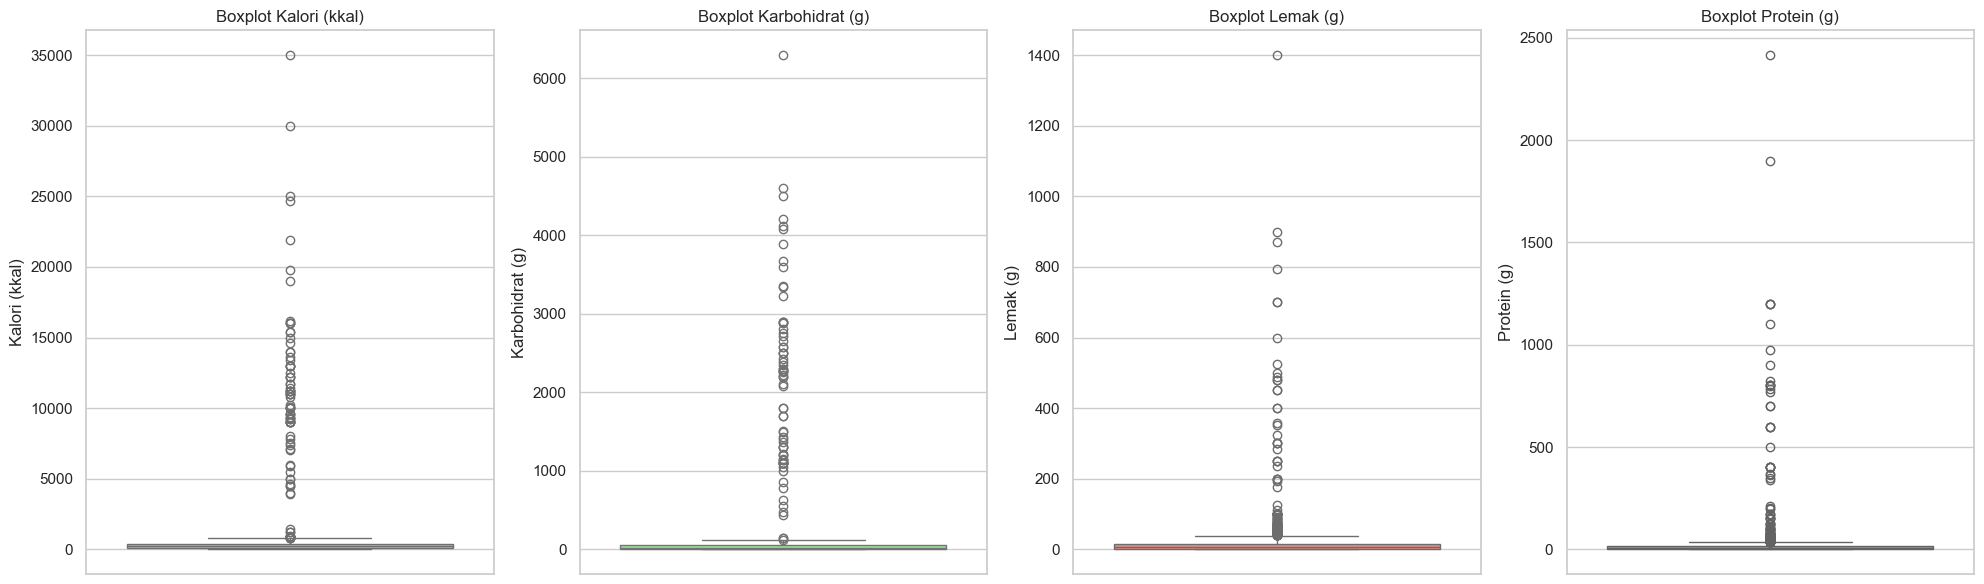

In [16]:
# 5. Mendeteksi Outlier dengan Boxplot
# Kita membuat kanvas besar dengan 1 baris dan 4 kolom
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

# Boxplot Kalori
sns.boxplot(y=df['Kalori (kkal)'], color='skyblue', ax=axes[0])
axes[0].set_title('Boxplot Kalori (kkal)', fontsize=12)

# Boxplot Karbohidrat
sns.boxplot(y=df['Karbohidrat (g)'], color='lightgreen', ax=axes[1])
axes[1].set_title('Boxplot Karbohidrat (g)', fontsize=12)

# Boxplot Lemak
sns.boxplot(y=df['Lemak (g)'], color='salmon', ax=axes[2])
axes[2].set_title('Boxplot Lemak (g)', fontsize=12)

# Boxplot Protein
sns.boxplot(y=df['Protein (g)'], color='orchid', ax=axes[3])
axes[3].set_title('Boxplot Protein (g)', fontsize=12)

# Merapikan jarak antar grafik
plt.tight_layout()
plt.show()

### **Analisis Visualisasi Boxplot**

Visualisasi boxplot ini memberikan gambaran yang paling jelas mengenai seberapa parah anomali data yang kita miliki:

1.  **Kompresi Data Utama:** Karena adanya nilai ekstrem (seperti 35.000 kkal atau 6.000g karbohidrat), kotak utama (IQR) yang mewakili 50% data tengah terlihat sangat tipis atau hampir menyerupai garis datar di angka 0. Ini menunjukkan bahwa nilai-nilai ekstrem tersebut berada ribuan kali lipat di atas median data.
2.  **Identifikasi Outlier:**
    *   Semua titik hitam di atas garis 'whisker' adalah outlier. Biasanya, outlier adalah variasi alami, namun di sini titik-titik tersebut membentuk garis vertikal yang sangat panjang, menandakan banyak data yang jauh dari kewajaran fungsional (kesalahan input/scraping).
    *   **Kalori:** Memiliki sebaran outlier yang paling jauh, mencapai angka 35.000.
    *   **Karbohidrat, Lemak, dan Protein:** Semuanya memiliki outlier yang melampaui angka 100, yang secara fisik mustahil untuk berat sampel 100 gram.

3.  **Kebutuhan Data Cleaning:** Boxplot ini membuktikan bahwa statistik rata-rata (*mean*) yang kita dapatkan sebelumnya tidak bisa diandalkan untuk analisis bisnis karena sangat terpengaruh oleh titik-titik ekstrem ini.

**Kesimpulan Akhir Tahap EDA:** Sebelum menjawab pertanyaan bisnis nomor 2 dan 3, kita harus melakukan pembersihan data dengan membatasi nilai makronutrisi maksimal 100g dan kalori pada batas yang logis (misalnya maks 900 kkal per 100g).

### **Menyimpan Dataset Versi Terbaru**

Menyimpan data ke dalam file `dataset_gizi_terupdate.csv` sesuai permintaan tanpa filtering tambahan.

In [17]:
# Menyimpan dataset ke file CSV
df.to_csv('dataset_gizi_terupdate.csv', index=False)

print(f"Dataset berhasil disimpan! Total baris: {len(df)}")
print("Nama file: dataset_gizi_terupdate.csv")

Dataset berhasil disimpan! Total baris: 3183
Nama file: dataset_gizi_terupdate.csv
